In [1]:
# 2. Preliminary Wrangling — Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid')

In [3]:
# Load the dataset

df = pd.read_csv('FordGoBike.csv')

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

Dataset shape: 183,416 rows × 16 columns


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.00,Montgomery St BART Station (Market St at 2nd St),37.79,-122.40,13.00,Commercial St at Montgomery St,37.79,-122.40,4902,Customer,"1,984.00",Male,No
1,42521,53:21.8,42:03.1,23.00,The Embarcadero at Steuart St,37.79,-122.39,81.00,Berry St at 4th St,37.78,-122.39,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.00,Market St at Dolores St,37.77,-122.43,3.00,Powell St BART Station (Market St at 4th St),37.79,-122.40,5905,Customer,"1,972.00",Male,No
3,36490,54:26.0,02:36.8,375.00,Grove St at Masonic Ave,37.77,-122.45,70.00,Central Ave at Fell St,37.77,-122.44,6638,Subscriber,"1,989.00",Other,No
4,1585,54:18.5,20:44.1,7.00,Frank H Ogawa Plaza,37.80,-122.27,222.00,10th Ave at E 15th St,37.79,-122.25,4898,Subscriber,"1,974.00",Male,Yes


In [4]:
# Basic structure

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame('dtype'))

print("\nDataset information:")
df.info()

Column names:
['duration_sec', 'start_time', 'end_time', 'start_station_id', 'start_station_name', 'start_station_latitude', 'start_station_longitude', 'end_station_id', 'end_station_name', 'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type', 'member_birth_year', 'member_gender', 'bike_share_for_all_trip']

Data types:


,dtype
duration_sec,int64
start_time,str
end_time,str
start_station_id,float64
start_station_name,str
start_station_latitude,float64
start_station_longitude,float64
end_station_id,float64
end_station_name,str
end_station_latitude,float64



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  float6

In [5]:
# Descriptive statistics

display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
duration_sec,"183,416.00",NaN,NaN,NaN,726.07,"1,794.37",61.00,325.00,514.00,796.00,"85,444.00"
start_time,183416,35783,12:19.2,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
end_time,183416,35767,22:24.4,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_station_id,"183,219.00",NaN,NaN,NaN,138.59,111.78,3.00,47.00,104.00,239.00,398.00
start_station_name,183219,329,Market St at 10th St,3904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_station_latitude,"183,416.00",NaN,NaN,NaN,37.77,0.10,37.32,37.77,37.78,37.80,37.88
start_station_longitude,"183,416.00",NaN,NaN,NaN,-122.35,0.12,-122.45,-122.41,-122.40,-122.29,-121.87
end_station_id,"183,219.00",NaN,NaN,NaN,136.25,111.51,3.00,44.00,100.00,235.00,398.00
end_station_name,183219,329,San Francisco Caltrain Station 2 (Townsend St...,4857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
end_station_latitude,"183,416.00",NaN,NaN,NaN,37.77,0.10,37.32,37.77,37.78,37.80,37.88


In [ ]:
# Missing values

missing = (
    df.isna()
      .sum()
      .to_frame('missing_count')
)

missing['missing_percentage'] = missing['missing_count'] / len(df) * 100
missing = missing.sort_values('missing_count', ascending=False)

display(missing)

,missing_count,missing_percentage
member_birth_year,8265,4.51
member_gender,8265,4.51
start_station_id,197,0.11
start_station_name,197,0.11
end_station_id,197,0.11
end_station_name,197,0.11
duration_sec,0,0.00
start_time,0,0.00
end_time,0,0.00
start_station_latitude,0,0.00


## 3. Data Assessment

The assessment stage identifies data-quality issues before any cleaning is performed. We will check:
- Missing values
- Duplicate rows
- Data types and formats
- Invalid values
- Categorical consistency
- Possible outliers

In [7]:
# Duplicate rows

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count:,}")
print(f"Percentage of duplicate rows: {duplicate_count / len(df) * 100:.2f}%")

Number of duplicate rows: 4
Percentage of duplicate rows: 0.00%


In [8]:
# Unique values and category consistency

categorical_cols = [
    col for col in ['user_type', 'member_gender', 'bike_share_for_all_trip']
    if col in df.columns
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False).to_frame('count'))


--- user_type ---


,count
user_type,
Subscriber,163548
Customer,19868



--- member_gender ---


,count
member_gender,
Male,130655
Female,40844
NaN,8265
Other,3652



--- bike_share_for_all_trip ---


,count
bike_share_for_all_trip,
No,166056
Yes,17360


In [9]:
# Numeric range checks

numeric_cols = [
    col for col in [
        'duration_sec',
        'start_station_id',
        'end_station_id',
        'member_birth_year',
        'start_station_latitude',
        'start_station_longitude',
        'end_station_latitude',
        'end_station_longitude'
    ]
    if col in df.columns
]

display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
duration_sec,"183,416.00",726.07,"1,794.37",61.00,325.00,514.00,796.00,"85,444.00"
start_station_id,"183,219.00",138.59,111.78,3.00,47.00,104.00,239.00,398.00
end_station_id,"183,219.00",136.25,111.51,3.00,44.00,100.00,235.00,398.00
member_birth_year,"175,151.00","1,984.81",10.12,"1,878.00","1,980.00","1,987.00","1,992.00","2,001.00"
start_station_latitude,"183,416.00",37.77,0.10,37.32,37.77,37.78,37.80,37.88
start_station_longitude,"183,416.00",-122.35,0.12,-122.45,-122.41,-122.40,-122.29,-121.87
end_station_latitude,"183,416.00",37.77,0.10,37.32,37.77,37.78,37.80,37.88
end_station_longitude,"183,416.00",-122.35,0.12,-122.45,-122.41,-122.40,-122.29,-121.87


In [10]:
# Check potentially invalid demographic values

if 'member_birth_year' in df.columns:
    current_year = 2019
    df['age_assessment'] = current_year - df['member_birth_year']

    print("Potentially invalid ages:")
    display(
        df.loc[
            (df['age_assessment'] < 18) | (df['age_assessment'] > 100),
            ['member_birth_year', 'age_assessment']
        ].head(20)
    )

Potentially invalid ages:


,member_birth_year,age_assessment
1285,"1,900.00",119.00
10827,"1,900.00",119.00
16087,"1,900.00",119.00
19375,"1,900.00",119.00
21424,"1,900.00",119.00
21506,"1,900.00",119.00
24042,"1,900.00",119.00
26133,"1,900.00",119.00
27370,"1,878.00",141.00
27675,"1,900.00",119.00


In [11]:
# Check trip-duration outliers using the IQR method

Q1 = df['duration_sec'].quantile(0.25)
Q3 = df['duration_sec'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df['duration_sec'] < lower_bound) | (df['duration_sec'] > upper_bound)

print(f"Q1: {Q1:,.2f} seconds")
print(f"Q3: {Q3:,.2f} seconds")
print(f"IQR: {IQR:,.2f} seconds")
print(f"Lower bound: {lower_bound:,.2f} seconds")
print(f"Upper bound: {upper_bound:,.2f} seconds")
print(f"Number of IQR outliers: {outlier_mask.sum():,}")

Q1: 325.00 seconds
Q3: 796.00 seconds
IQR: 471.00 seconds
Lower bound: -381.50 seconds
Upper bound: 1,502.50 seconds
Number of IQR outliers: 10,131


## 4. Data Cleaning

The cleaning steps below address the issues found during assessment:
- Remove exact duplicate rows.
- Standardize categorical missing values as `Unknown` where appropriate.
- Create a reliable age variable from birth year.
- Remove clearly invalid ages rather than removing all statistical outliers.
- Create trip duration in minutes.
- Standardize the gender representation.

In [12]:
# Work on a copy

clean_df = df.copy()

# Remove exact duplicates
before = len(clean_df)
clean_df = clean_df.drop_duplicates().copy()
print(f"Removed {before - len(clean_df):,} duplicate rows.")

Removed 4 duplicate rows.


In [13]:
# Standardize categorical missing values

if 'member_gender' in clean_df.columns:
    clean_df['member_gender'] = clean_df['member_gender'].fillna('Unknown').astype(str).str.strip()

if 'user_type' in clean_df.columns:
    clean_df['user_type'] = clean_df['user_type'].fillna('Unknown').astype(str).str.strip()

if 'bike_share_for_all_trip' in clean_df.columns:
    clean_df['bike_share_for_all_trip'] = (
        clean_df['bike_share_for_all_trip']
        .fillna('Unknown')
        .astype(str)
        .str.strip()
    )

display(clean_df[['user_type', 'member_gender', 'bike_share_for_all_trip']].head())

,user_type,member_gender,bike_share_for_all_trip
0,Customer,Male,No
1,Customer,Unknown,No
2,Customer,Male,No
3,Subscriber,Other,No
4,Subscriber,Male,Yes


In [14]:
# Create age and remove clearly invalid ages

REFERENCE_YEAR = 2019

clean_df['age'] = REFERENCE_YEAR - clean_df['member_birth_year']

invalid_age_mask = (
    clean_df['age'].notna() &
    ((clean_df['age'] < 18) | (clean_df['age'] > 100))
)

print(f"Invalid age records identified: {invalid_age_mask.sum():,}")

clean_df.loc[invalid_age_mask, 'age'] = np.nan

Invalid age records identified: 72


In [15]:
# Create trip duration in minutes

clean_df['duration_min'] = clean_df['duration_sec'] / 60
clean_df['duration_hrs'] = clean_df['duration_min'] / 60

display(clean_df[['duration_sec', 'duration_min', 'duration_hrs']].head())

,duration_sec,duration_min,duration_hrs
0,52185,869.75,14.50
1,42521,708.68,11.81
2,61854,"1,030.90",17.18
3,36490,608.17,10.14
4,1585,26.42,0.44


In [16]:
# Standardize gender values

gender_map = {
    'Male': 'Male',
    'Female': 'Female',
    'Other': 'Other',
    'Unknown': 'Unknown'
}

clean_df['member_gender'] = clean_df['member_gender'].replace(gender_map)

print(clean_df['member_gender'].value_counts(dropna=False))

member_gender
Male       130651
Female      40844
Unknown      8265
Other        3652
Name: count, dtype: int64


In [17]:
# Final cleaning check

print(f"Cleaned dataset shape: {clean_df.shape[0]:,} rows × {clean_df.shape[1]} columns")

print("\nMissing values after cleaning:")
final_missing = (
    clean_df.isna().sum()
    .to_frame('missing_count')
)
final_missing['missing_percentage'] = final_missing['missing_count'] / len(clean_df) * 100
display(final_missing[final_missing['missing_count'] > 0].sort_values('missing_count', ascending=False))

Cleaned dataset shape: 183,412 rows × 20 columns

Missing values after cleaning:


,missing_count,missing_percentage
age,8337,4.55
member_birth_year,8265,4.51
age_assessment,8265,4.51
start_station_id,197,0.11
start_station_name,197,0.11
end_station_id,197,0.11
end_station_name,197,0.11


## 5. Feature Engineering

New analytical features:
- `duration_min`: trip duration in minutes.
- `duration_hrs`: trip duration in hours.
- `age`: rider age based on the 2019 reference year.
- `age_group`: grouped rider ages.
- `is_weekend`: weekend indicator based on a valid date, when a full date is available.

The provided `start_time`/`end_time` fields are also inspected before creating date-based features.

In [18]:
# Age groups

age_bins = [0, 29, 54, np.inf]
age_labels = ['Young', 'Adult', 'Senior']

clean_df['age_group'] = pd.cut(
    clean_df['age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

display(clean_df['age_group'].value_counts(dropna=False).to_frame('count'))

,count
age_group,
Adult,100686
Young,65383
Senior,9006
NaN,8337


In [19]:
# Inspect the time fields before deriving calendar features

for col in ['start_time', 'end_time']:
    if col in clean_df.columns:
        print(f"\n{col} sample values:")
        display(clean_df[col].head(10))

# Attempt parsing as datetime without inventing dates
if 'start_time' in clean_df.columns:
    parsed_start = pd.to_datetime(clean_df['start_time'], errors='coerce')
    print(f"\nValid full datetime values in start_time: {parsed_start.notna().sum():,} / {len(clean_df):,}")


start_time sample values:


0    32:10.1
1    53:21.8
2    13:13.2
3    54:26.0
4    54:18.5
5    49:58.6
6    55:35.1
7    41:06.8
8    41:48.8
9    49:47.7
Name: start_time, dtype: str


end_time sample values:


0    01:56.0
1    42:03.1
2    24:08.1
3    02:36.8
4    20:44.1
5    19:51.8
6    14:42.6
7    08:02.8
8    07:59.7
9    07:17.0
Name: end_time, dtype: str

C:\Users\habiba\AppData\Local\Temp\ipykernel_7560\4006359889.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_start = pd.to_datetime(clean_df['start_time'], errors='coerce')



Valid full datetime values in start_time: 73,911 / 183,412


# 6. Exploratory Data Analysis

## 6.1 Univariate Analysis

We first examine individual variables and their distributions.

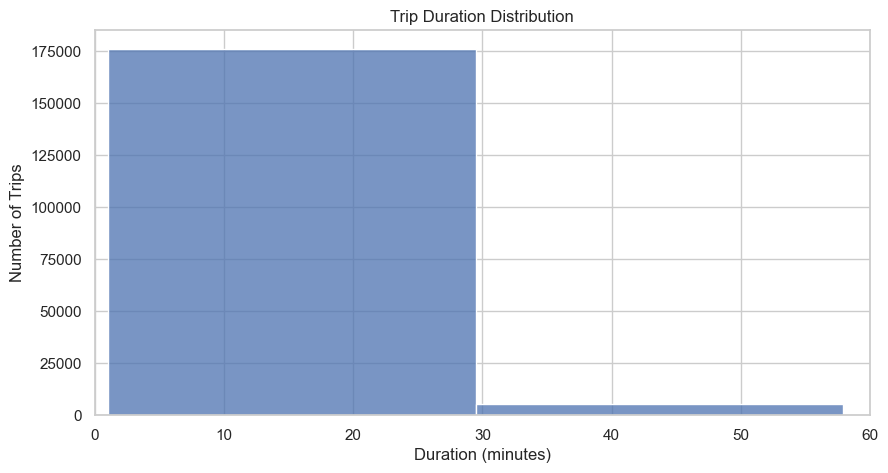

Interpretation:
The distribution is concentrated around shorter trips, with a right tail representing longer rides.


In [20]:
# Trip duration distribution

plt.figure(figsize=(10, 5))
sns.histplot(clean_df['duration_min'].dropna(), bins=50)
plt.xlim(0, 60)
plt.title('Trip Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Trips')
plt.show()

print("Interpretation:")
print("The distribution is concentrated around shorter trips, with a right tail representing longer rides.")

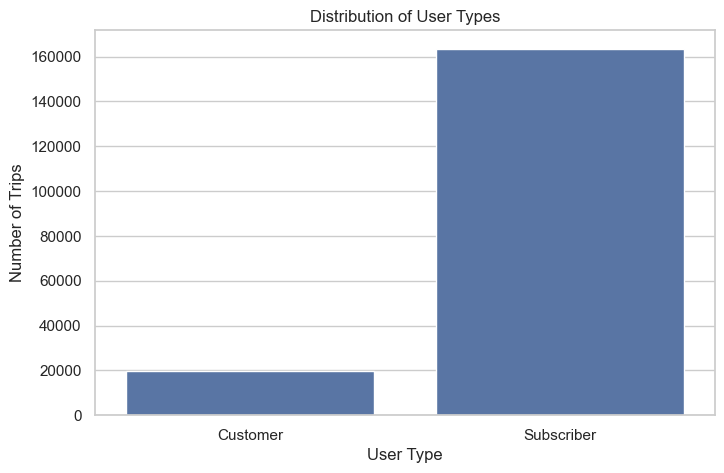

,trip_count
user_type,
Subscriber,163544
Customer,19868


In [21]:
# User type distribution

plt.figure(figsize=(8, 5))
sns.countplot(data=clean_df, x='user_type')
plt.title('Distribution of User Types')
plt.xlabel('User Type')
plt.ylabel('Number of Trips')
plt.show()

display(clean_df['user_type'].value_counts().to_frame('trip_count'))

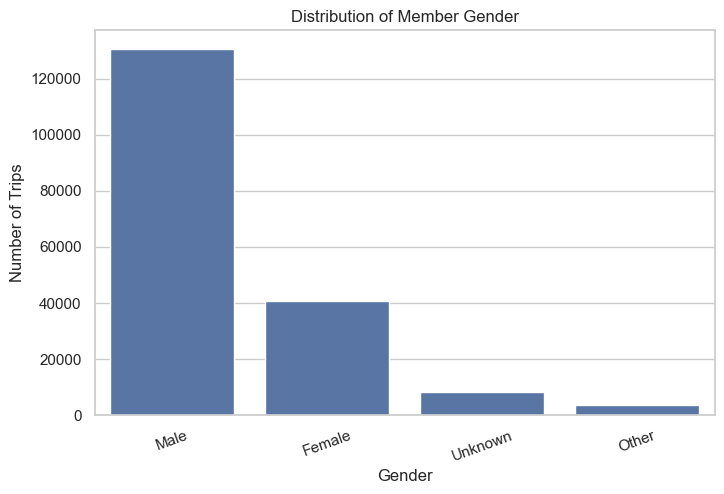

,trip_count
member_gender,
Male,130651
Female,40844
Unknown,8265
Other,3652


In [22]:
# Gender distribution

plt.figure(figsize=(8, 5))
sns.countplot(data=clean_df, x='member_gender', order=clean_df['member_gender'].value_counts().index)
plt.title('Distribution of Member Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Trips')
plt.xticks(rotation=20)
plt.show()

display(clean_df['member_gender'].value_counts().to_frame('trip_count'))

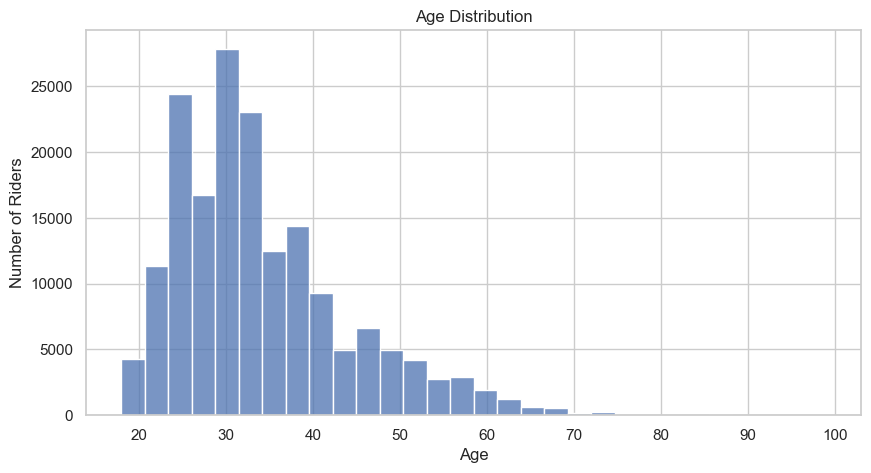

Median age: 32.0


In [23]:
# Age distribution

plt.figure(figsize=(10, 5))
sns.histplot(clean_df['age'].dropna(), bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Riders')
plt.show()

print(f"Median age: {clean_df['age'].median():.1f}")

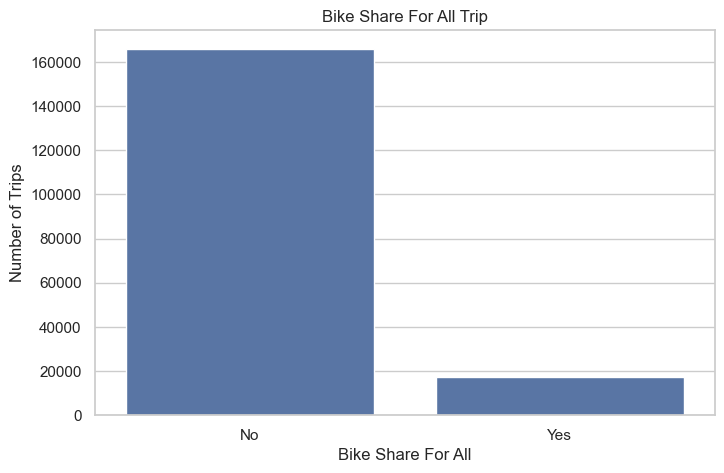

In [24]:
# Bike Share For All Trip

plt.figure(figsize=(8, 5))
sns.countplot(data=clean_df, x='bike_share_for_all_trip')
plt.title('Bike Share For All Trip')
plt.xlabel('Bike Share For All')
plt.ylabel('Number of Trips')
plt.show()

## 6.2 Bivariate Analysis

Next, we examine relationships between two variables.

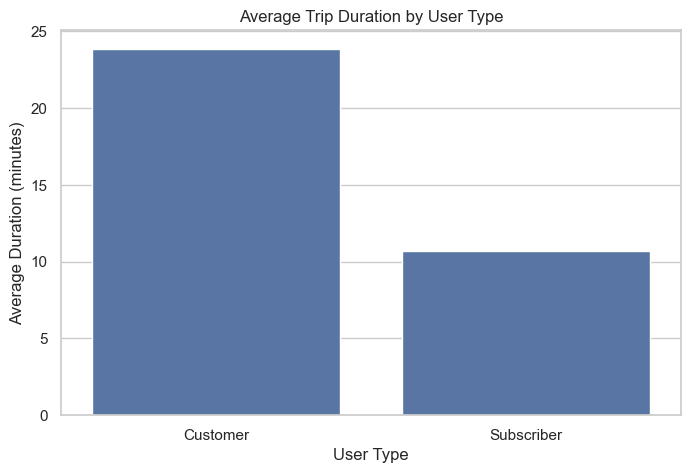

,average_duration_min
user_type,
Customer,23.87
Subscriber,10.67


In [25]:
# Average duration by user type

avg_duration_user = (
    clean_df.groupby('user_type', dropna=False)['duration_min']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=avg_duration_user.index,
    y=avg_duration_user.values
)
plt.title('Average Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Average Duration (minutes)')
plt.show()

display(avg_duration_user.to_frame('average_duration_min'))

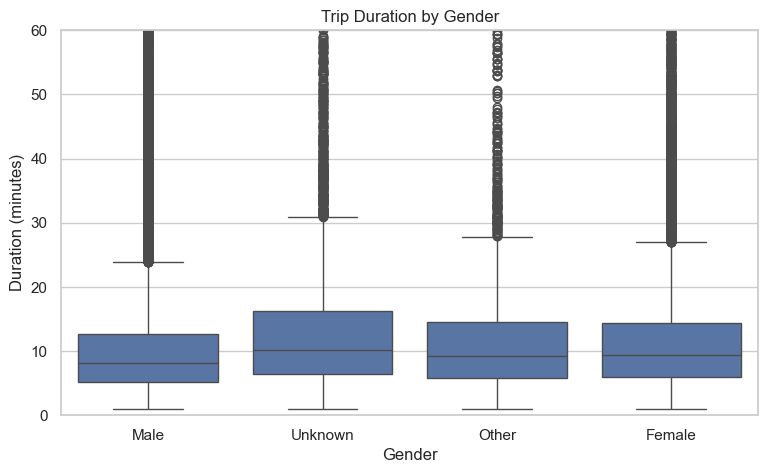

,count,mean,median
member_gender,,,
Unknown,8265,19.82,10.10
Other,3652,16.61,9.25
Female,40844,12.98,9.47
Male,130651,11.21,8.22


In [26]:
# Trip duration by gender

plt.figure(figsize=(9, 5))
sns.boxplot(data=clean_df, x='member_gender', y='duration_min')
plt.ylim(0, 60)
plt.title('Trip Duration by Gender')
plt.xlabel('Gender')
plt.ylabel('Duration (minutes)')
plt.show()

display(
    clean_df.groupby('member_gender')['duration_min']
    .agg(['count', 'mean', 'median'])
    .sort_values('mean', ascending=False)
)

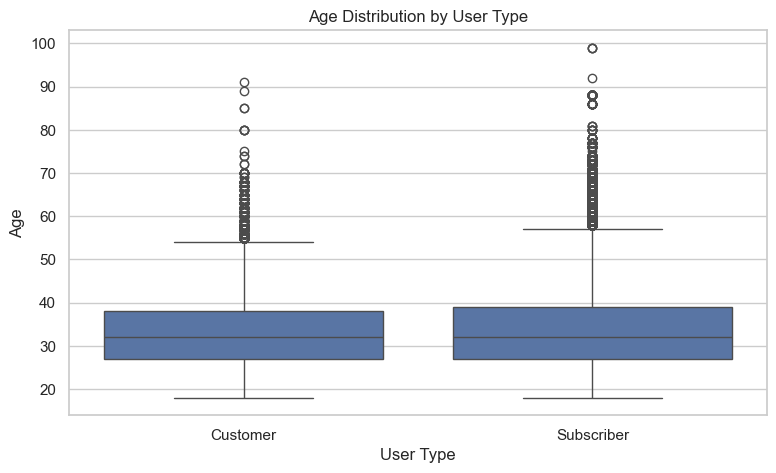

,count,mean,median,min,max
user_type,,,,,
Customer,16626,33.61,32.00,18.00,91.00
Subscriber,158449,34.22,32.00,18.00,99.00


In [27]:
# Age by user type

plt.figure(figsize=(9, 5))
sns.boxplot(data=clean_df, x='user_type', y='age')
plt.title('Age Distribution by User Type')
plt.xlabel('User Type')
plt.ylabel('Age')
plt.show()

display(
    clean_df.groupby('user_type')['age']
    .agg(['count', 'mean', 'median', 'min', 'max'])
)

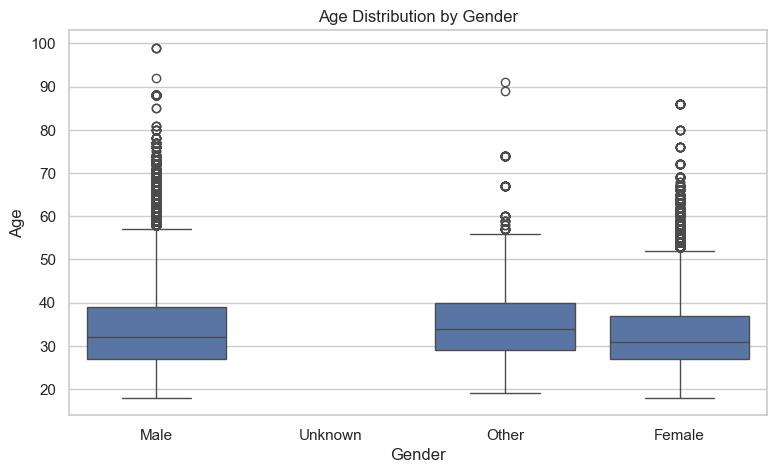

,count,mean,median,min,max
member_gender,,,,,
Female,40830,33.19,31.00,18.00,86.00
Male,130594,34.41,32.00,18.00,99.00
Other,3651,35.86,34.00,19.00,91.00
Unknown,0,NaN,NaN,NaN,NaN


In [28]:
# Age by gender

plt.figure(figsize=(9, 5))
sns.boxplot(data=clean_df, x='member_gender', y='age')
plt.title('Age Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()

display(
    clean_df.groupby('member_gender')['age']
    .agg(['count', 'mean', 'median', 'min', 'max'])
)

## 6.3 Multivariate Analysis

Finally, we examine relationships among several numeric variables using correlation analysis.

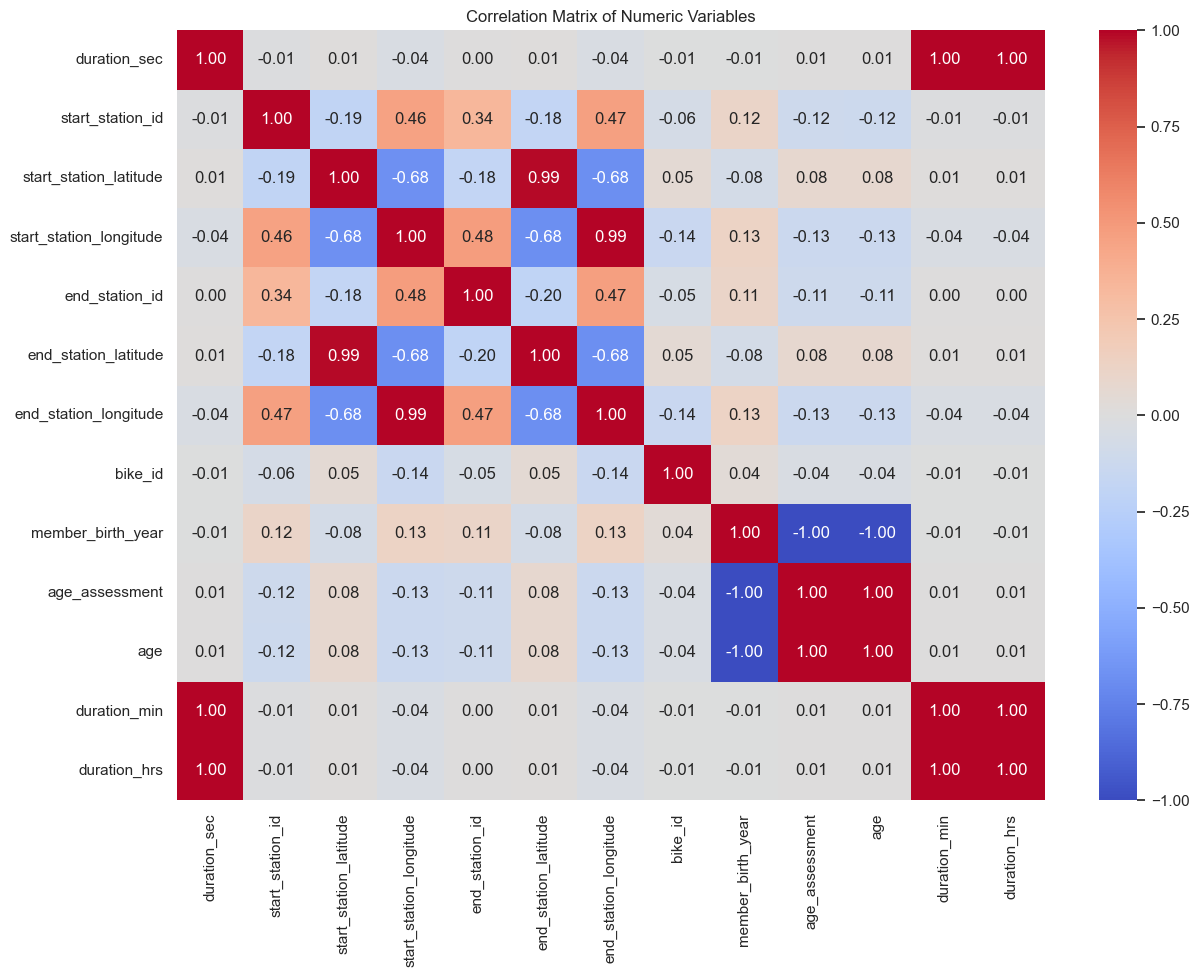

In [29]:
# Correlation matrix — all numeric variables

numeric_df = clean_df.select_dtypes(include=np.number)
corr_all = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

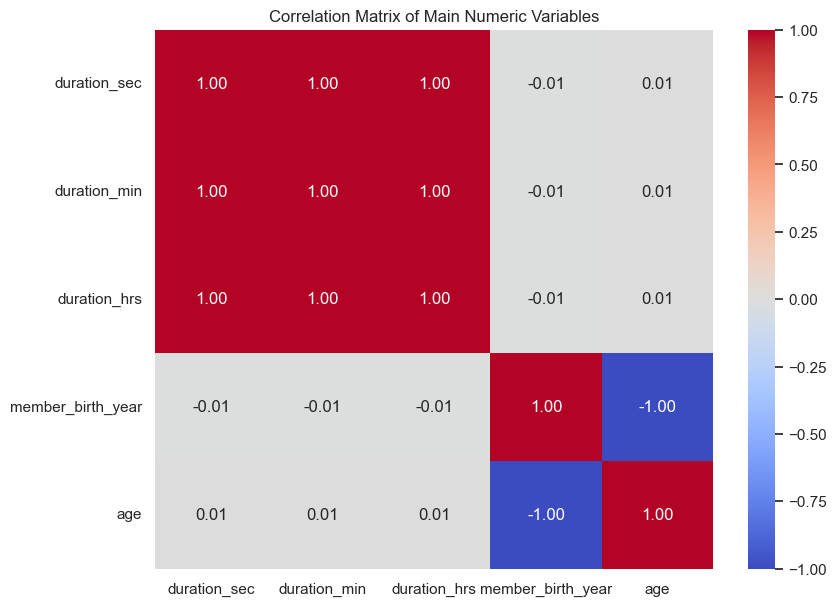

In [30]:
# Focused correlation matrix

candidate_cols = [
    'duration_sec',
    'duration_min',
    'duration_hrs',
    'member_birth_year',
    'age'
]

selected_cols = [col for col in candidate_cols if col in clean_df.columns]

corr_selected = clean_df[selected_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_selected, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Main Numeric Variables')
plt.show()

In [31]:
# Optional: save the cleaned dataset

output_path = 'preprocessed_fordgobike_phase1.csv'
clean_df.to_csv(output_path, index=False)

print(f"Saved cleaned dataset to: {output_path}")

Saved cleaned dataset to: preprocessed_fordgobike_phase1.csv
